In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
import seaborn as sns
from generating_dataset import dataset,true_beta
from palette import palette
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


In [3]:
X,y = dataset
n,p = X.shape[0],X.shape[1]-1

### <b> EXPERIMENT 7.2.2 Prior Information Sensitivity (different g-prior scenarios)

In [4]:
XtX = X.T @ X
inv_XtX = np.linalg.inv(XtX)
beta_ols = inv_XtX @ X.T @ y
SSE = np.sum((y - X @ beta_ols)**2)

a1_ind = (n-(p+1)) / 2.0
b1_ind = SSE / 2.0
df_ind = 2*a1_ind
mean_ind = beta_ols
sd_ind = np.sqrt((b1_ind / a1_ind) * np.diag(inv_XtX))

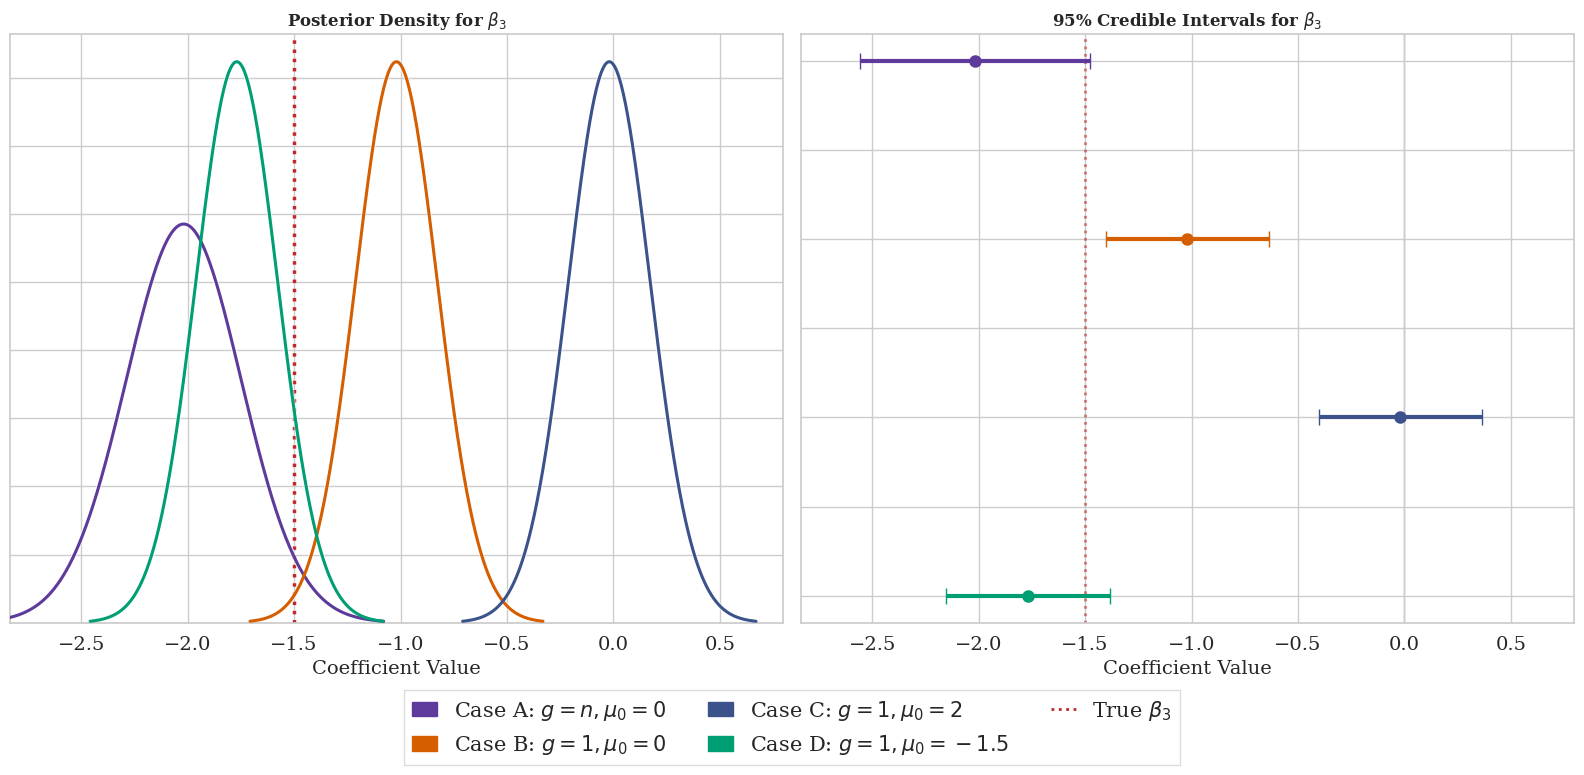

In [5]:
sns.set_theme(style="whitegrid", font="serif")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 1]})

target_idx = 3
g_val = 1.0


cases = [
    {'label': 'Case A: $g=n, \mu_0=0$', 'g': n,     'mu0': 0.0,  'color': palette.ols},
    {'label': 'Case B: $g=1, \mu_0=0$', 'g': g_val, 'mu0': 0.0,  'color': palette.joint},
    {'label': 'Case C: $g=1, \mu_0=2$', 'g': g_val, 'mu0': 2.0,  'color': palette.bars}, 
    {'label': 'Case D: $g=1, \mu_0=-1.5$', 'g': g_val, 'mu0': -1.5, 'color': palette.gprior}
]

means_3, scales_3, mes_3 = [], [], []
for case in cases:
    m_post = (case['g'] / (case['g'] + 1)) * mean_ind[target_idx] + (1 / (case['g'] + 1)) * case['mu0']
    s_post = np.sqrt(case['g'] / (case['g'] + 1)) * sd_ind[target_idx]
    me_post = t.ppf(0.975, df=df_ind) * s_post
    means_3.append(m_post)
    scales_3.append(s_post)
    mes_3.append(me_post)

x_min_calc = min(means_3) - 5 * max(scales_3)
x_max_calc = max(means_3) + 5 * max(scales_3)
x_rango = np.linspace(x_min_calc, x_max_calc, 2000)

for i, case in enumerate(cases):
    pdf = t.pdf(x_rango, df=df_ind, loc=means_3[i], scale=scales_3[i])
    
    mask = pdf > 0.005 
    
    ax1.plot(x_rango[mask], pdf[mask], color='white', linewidth=4, alpha=0.5, zorder=2)
    ax1.plot(x_rango[mask], pdf[mask], color=case['color'], 
             linewidth=palette.line_width_thick, zorder=3)

ax1.axvline(true_beta[target_idx], color=palette.true_red, linestyle=':', linewidth=2.5, zorder=1)
ax1.set_title(f"Posterior Density for $\\beta_{{{target_idx}}}$", fontweight='bold')
ax1.set_xlabel("Coefficient Value",fontsize=14)

ax1.set_ylim(0, None)
ax1.tick_params(axis='y', labelleft=False)
ax1.tick_params(axis='x',labelsize=14)


y_pos_cases = np.arange(4)
ax2.axvline(true_beta[target_idx], color=palette.true_red, linestyle=':', linewidth=2, alpha=0.6, zorder=1)
ax2.axvline(0, color=palette.zero_gray, linewidth=1, alpha=0.4, zorder=0)

for i, case in enumerate(cases):
    ax2.errorbar(means_3[i], y_pos_cases[i], xerr=mes_3[i], 
                 fmt='o', color=case['color'], markersize=8, linewidth=3, 
                 capsize=6, zorder=3)

ax2.set_title(f"95% Credible Intervals for $\\beta_{{{target_idx}}}$", fontweight='bold')
ax2.set_xlabel("Coefficient Value",fontsize=14)
ax2.invert_yaxis()
ax2.set_yticklabels([]) 
ax2.tick_params(axis='y', left=False) 
ax2.tick_params(axis='x',labelsize=14)

visible_min = min(means_3) - 3 * max(scales_3)
visible_max = max(means_3) + 3 * max(scales_3)
ax1.set_xlim(visible_min, visible_max)
ax2.set_xlim(visible_min, visible_max)

color_proxies = [mpatches.Patch(color=c['color'], label=c['label']) for c in cases]
true_val_proxy = Line2D([0], [0], color=palette.true_red, linestyle=':', linewidth=2, label=f"True $\\beta_{{{target_idx}}}$")

fig.legend(handles=color_proxies + [true_val_proxy], 
           loc='lower center', bbox_to_anchor=(0.5, 0.02), 
           ncol=3, frameon=True, edgecolor='#D3D3D3', fancybox=False,
           fontsize=15, handlelength=1.2, handleheight=0.7)

plt.tight_layout(rect=[0, 0.12, 1, 1]) 
plt.savefig("../graphics/prior_sensitivity_analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()

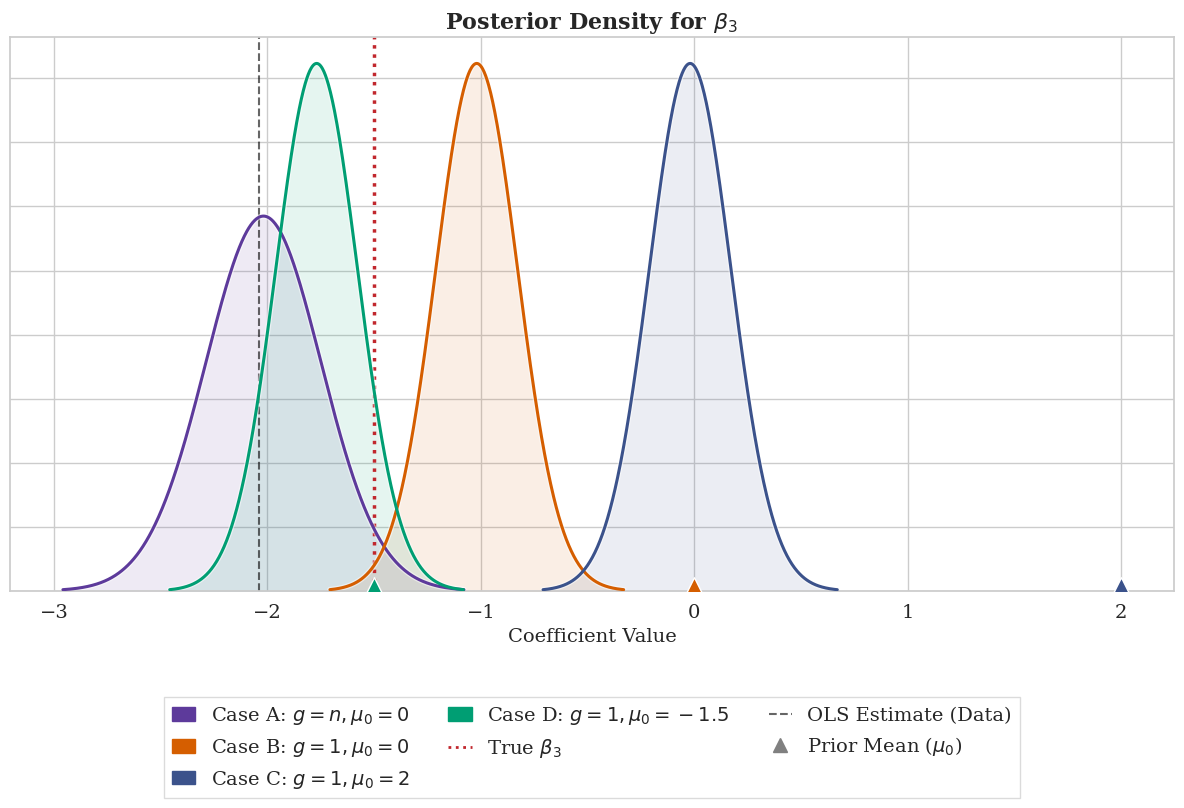

In [6]:
sns.set_theme(style="whitegrid", font="serif")
fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

target_idx = 3
g_val = 1.0

cases = [
    {'label': 'Case A: $g=n, \mu_0=0$', 'g': n,     'mu0': 0.0,  'color': palette.ols},
    {'label': 'Case B: $g=1, \mu_0=0$', 'g': g_val, 'mu0': 0.0,  'color': palette.joint},
    {'label': 'Case C: $g=1, \mu_0=2$', 'g': g_val, 'mu0': 2.0,  'color': palette.bars}, 
    {'label': 'Case D: $g=1, \mu_0=-1.5$', 'g': g_val, 'mu0': -1.5, 'color': palette.gprior}
]

means_3, scales_3, mes_3 = [], [], []
for case in cases:
    m_post = (case['g'] / (case['g'] + 1)) * mean_ind[target_idx] + (1 / (case['g'] + 1)) * case['mu0']
    s_post = np.sqrt(case['g'] / (case['g'] + 1)) * sd_ind[target_idx]
    me_post = t.ppf(0.975, df=df_ind) * s_post
    means_3.append(m_post)
    scales_3.append(s_post)
    mes_3.append(me_post)

x_min_calc = min(means_3) - 5 * max(scales_3)
x_max_calc = max(means_3) + 5 * max(scales_3)
x_rango = np.linspace(x_min_calc, x_max_calc, 2000)

for i, case in enumerate(cases):
    pdf = t.pdf(x_rango, df=df_ind, loc=means_3[i], scale=scales_3[i])
    
    mask = pdf > 0.005 
    
    ax1.fill_between(x_rango[mask], 0, pdf[mask], color=case['color'], alpha=0.1, zorder=1)
    
    ax1.plot(x_rango[mask], pdf[mask], color='white', linewidth=4, alpha=0.5, zorder=2)
    
    ax1.plot(x_rango[mask], pdf[mask], color=case['color'], 
             linewidth=palette.line_width_thick, zorder=3)
             
    if i != 0:
        ax1.scatter(case['mu0'], 0.02, color=case['color'], marker='^', s=160, 
                    edgecolor='white', linewidth=1, zorder=4)

ax1.axvline(true_beta[target_idx], color=palette.true_red, linestyle=':', linewidth=2.5, zorder=1)

ols_estimate = mean_ind[target_idx]
ax1.axvline(ols_estimate, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

ax1.set_title(f"Posterior Density for $\\beta_{{{target_idx}}}$", fontweight='bold', fontsize=16)
ax1.set_xlabel("Coefficient Value", fontsize=14)

ax1.set_ylim(0, None)
ax1.tick_params(axis='y', labelleft=False)
ax1.tick_params(axis='x', labelsize=14)

color_proxies = [mpatches.Patch(color=c['color'], label=c['label']) for c in cases]
true_val_proxy = Line2D([0], [0], color=palette.true_red, linestyle=':', linewidth=2, label=f"True $\\beta_{{{target_idx}}}$")
ols_proxy = Line2D([0], [0], color='black', linestyle='--', linewidth=1.5, alpha=0.6, label="OLS Estimate (Data)")
prior_mean_proxy = Line2D([0], [0], color='gray', marker='^', linestyle='None', markersize=10, label="Prior Mean ($\\mu_0$)")

fig.legend(handles=color_proxies + [true_val_proxy, ols_proxy, prior_mean_proxy], 
           loc='lower center', bbox_to_anchor=(0.5, -0.02), 
           ncol=3, frameon=True, edgecolor='#D3D3D3', fancybox=False,
           fontsize=14, handlelength=1.2, handleheight=0.7)

plt.tight_layout(rect=[0, 0.16, 1, 1]) 
plt.savefig("../graphics/prior_sensitivity_analysis_distributions.pdf", dpi=300, bbox_inches='tight')
plt.show()